In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

In [2]:
df = pd.read_csv('final_dataset.csv')  


print(df.shape)
df.head()

(1050, 15)


,TransactionID,Date,Time,Company,LocationID,City,FuelType,Quantity_Liters,Price_per_Litre,Total_Amount,PaymentMethod,VehicleType,LoyaltyCardUsed,PumpNumber,EmployeeID
0,TXN001,2024-01-03,05:44:00,HP,delhi-pump-04,delhi,petrol,26.30,94.46,2484.30,UPI,car,No,3,E-DEL-4
1,TXN002,2025-02-04,21:08:00,IOCL,pune-pump-01,pune,diesel,42.89,87.57,3755.88,Card,car,Yes,5,E-PUN-3
2,TXN003,2024-08-25,06:39:00,BPCL,mumbai-pump-02,mumbai,diesel,10.42,88.11,918.11,Card,bike,Yes,1,E-MUM-2
3,TXN004,2025-01-05,15:20:00,IOCL,bangalore-pump-07,bangalore,petrol,14.49,95.10,1378.00,Cash,bike,No,2,E-BAN-1
4,TXN005,2025-04-09,19:52:00,HP,mumbai-pump-02,mumbai,diesel,39.37,87.21,3433.46,Cash,car,No,5,E-MUM-5


In [3]:
# STEP 2: Convert the date column, group sales by day
df['Date'] = pd.to_datetime(df['Date'])
daily_sales = df.groupby('Date').agg({'Total_Amount': 'sum'})
daily_sales.head()

,Total_Amount
Date,
2024-01-01,4061.05
2024-01-02,4326.18
2024-01-03,10197.08
2024-01-04,5632.04
2024-01-05,5354.86


In [4]:
train = daily_sales.iloc[:-7]
test = daily_sales.iloc[-7:]

In [5]:
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

c:\Users\Keerthish\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Keerthish\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Keerthish\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [6]:
# STEP 5: Forecast the next 7 days
forecast = model_fit.forecast(steps=7)

c:\Users\Keerthish\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Keerthish\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


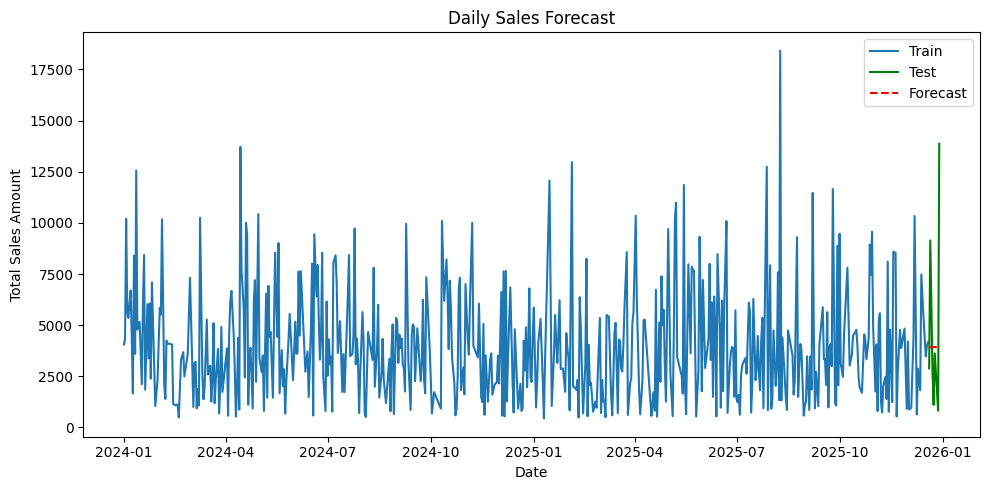

In [7]:
# STEP 6: Plot results (train, test, forecast)
plt.figure(figsize=(10,5))
plt.plot(train.index, train['Total_Amount'], label='Train')
plt.plot(test.index, test['Total_Amount'], label='Test', color='green')
plt.plot(test.index, forecast, label='Forecast', color='red', linestyle='dashed')
plt.title('Daily Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Total Sales Amount')
plt.legend()
plt.tight_layout()
plt.show()

predicting volume using price, city, company

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [9]:
# 2. Encode Categorical Features (City, Company)
data_encoded = pd.get_dummies(df, columns=['City', 'Company'], drop_first=True)


In [10]:
X = data_encoded[['Price_per_Litre'] + [col for col in data_encoded.columns if col.startswith('City_') or col.startswith('Company_')]]
y = data_encoded['Quantity_Liters']


In [11]:
# 4. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [12]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [13]:
# 6. Predict and Evaluate
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Absolute Error: {mae:.2f}')
print(f'R^2 Score: {r2:.2f}')


Mean Absolute Error: 12.22
R^2 Score: -0.19


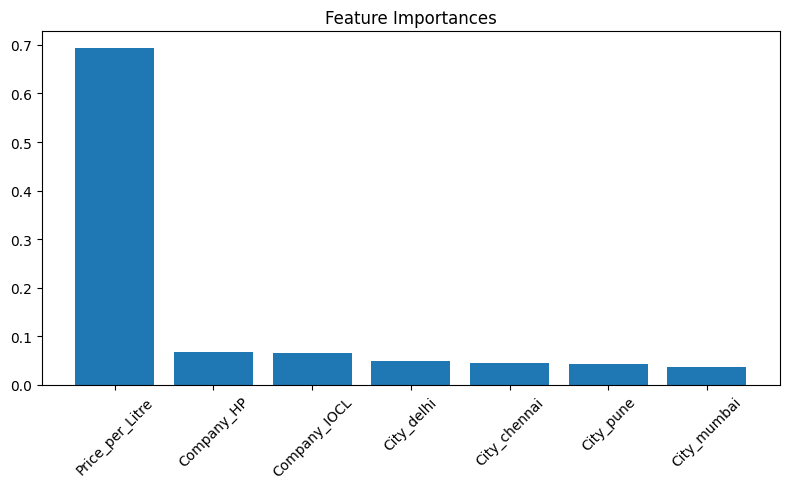

In [14]:
feature_importances = model.feature_importances_
features = X.columns
indices = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(8,5))
plt.title("Feature Importances")
plt.bar(range(len(features)), feature_importances[indices], align="center")
plt.xticks(range(len(features)), [features[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()